In [1]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from tqdm import tqdm
from keras.callbacks import EarlyStopping,ModelCheckpoint
from sklearn.metrics import confusion_matrix , accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
image_data=r"/content/drive/MyDrive/dataset/Faulty_solar_panel"
pd.DataFrame(os.listdir(image_data),columns=['Files_Name'])

,Files_Name
0,.DS_Store
1,Physical-Damage
2,Electrical-damage
3,Dusty
4,Clean
5,Snow-Covered
6,Bird-drop


In [3]:
train_data_dir =image_data
batch_size = 32
target_size = (224,224)
validation_split = 0.2
train= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="training",
    seed=100,
    image_size=target_size,
    batch_size=batch_size,
)
validation= tf.keras.preprocessing.image_dataset_from_directory(
    train_data_dir,
    validation_split=validation_split,
    subset="validation",
    seed=200,
    image_size=target_size,
    batch_size=batch_size,
)

Found 885 files belonging to 6 classes.
Using 708 files for training.
Found 885 files belonging to 6 classes.
Using 177 files for validation.


In [4]:
class_names = train.class_names
class_names

['Bird-drop',
 'Clean',
 'Dusty',
 'Electrical-damage',
 'Physical-Damage',
 'Snow-Covered']

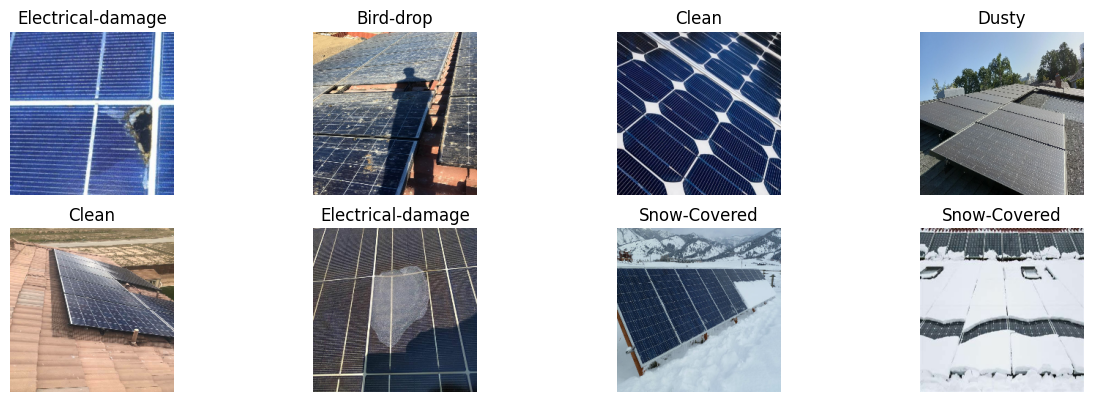

In [5]:
plt.figure(figsize=(15, 20))
for images, labels in train.take(1):
    for i in range(8):
        ax = plt.subplot(8, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
base_model = tf.keras.applications.MobileNetV3Small(input_shape=(224,224,3),include_top=False,weights='imagenet')
base_model.trainable = False
keras_model=keras.models.Sequential()
keras_model.add(base_model)
keras_model.add(keras.layers.Flatten())
keras_model.add(keras.layers.Dropout(0.5))
keras_model.add(keras.layers.Dense(6,activation=tf.nn.softmax))
keras_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       169,350 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,108,470 (4.23 MB)

 Trainable params: 169,350 (661.52 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [6]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

keras_model = keras.models.Sequential([
    keras.layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),
    base_model,
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation=tf.nn.softmax)
])
keras_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       376,326 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,634,310 (10.05 MB)

 Trainable params: 376,326 (1.44 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
keras_model.build()

In [8]:
checkpoint =ModelCheckpoint("kkeras_model.keras", save_best_only=True)

In [9]:
early_stopping =EarlyStopping(patience=5, restore_best_weights=True)

In [10]:
keras_model.compile(optimizer ='adam',loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist=keras_model.fit(train,epochs=25,validation_data=validation,callbacks=[checkpoint,early_stopping])

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 113s 5s/step - accuracy: 0.5678 - loss: 4.1809 - val_accuracy: 0.8588 - val_loss: 1.0930
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8969 - loss: 0.6619 - val_accuracy: 0.9096 - val_loss: 0.7078
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.9520 - loss: 0.3515 - val_accuracy: 0.9209 - val_loss: 0.8137
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.9774 - loss: 0.1014 - val_accuracy: 0.9379 - val_loss: 0.6142
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9746 - loss: 0.1071 - val_accuracy: 0.8983 - val_loss: 0.9934
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.9788 - loss: 0.1523 - val_accuracy: 0.9435 - val_loss: 0.7374
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9859 - loss: 0.0826 - val_accuracy: 0.9322 - val_loss: 0.8837
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.9760 - loss: 0.1785 - val_accuracy: 0.9379 - val_loss

In [11]:
hist_=pd.DataFrame(hist.history)
hist_

,accuracy,loss,val_accuracy,val_loss
0,0.567797,4.180933,0.858757,1.093004
1,0.896893,0.661917,0.909605,0.707809
2,0.951977,0.351513,0.920904,0.813686
3,0.977401,0.101402,0.937853,0.614181
4,0.974576,0.107085,0.898305,0.993398
5,0.978814,0.152346,0.943503,0.737395
6,0.985876,0.082574,0.932203,0.883675
7,0.975989,0.178502,0.937853,0.771418
8,0.988701,0.066705,0.943503,0.825304


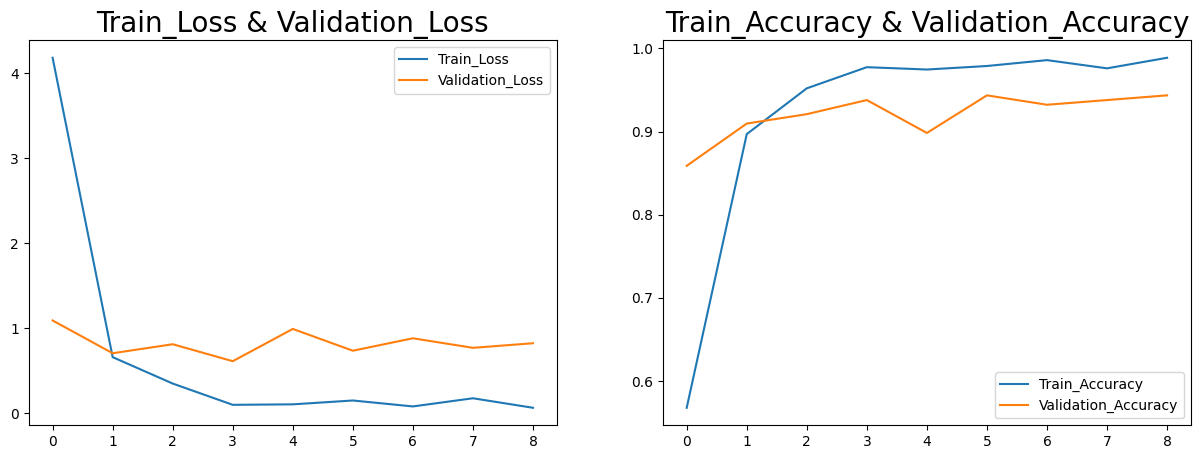

In [12]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(hist_['loss'],label='Train_Loss')
plt.plot(hist_['val_loss'],label='Validation_Loss')
plt.title('Train_Loss & Validation_Loss',fontsize=20)
plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_['accuracy'],label='Train_Accuracy')
plt.plot(hist_['val_accuracy'],label='Validation_Accuracy')
plt.title('Train_Accuracy & Validation_Accuracy',fontsize=20)
plt.legend()

In [14]:
X_val,y_val,y_pred=[],[],[]
for images, labels in validation:
    y_val.extend(labels.numpy())
    X_val.extend(images.numpy())
predictions=keras_model.predict(np.array(X_val))
for i in predictions:
    y_pred.append(np.argmax(i))
df=pd.DataFrame()
df['Actual'],df['Prediction']=y_val,y_pred
df

6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step


,Actual,Prediction
0,3,3
1,1,1
2,4,4
3,5,5
4,3,3
...,...,...
172,0,0
173,0,0
174,5,5
175,2,2


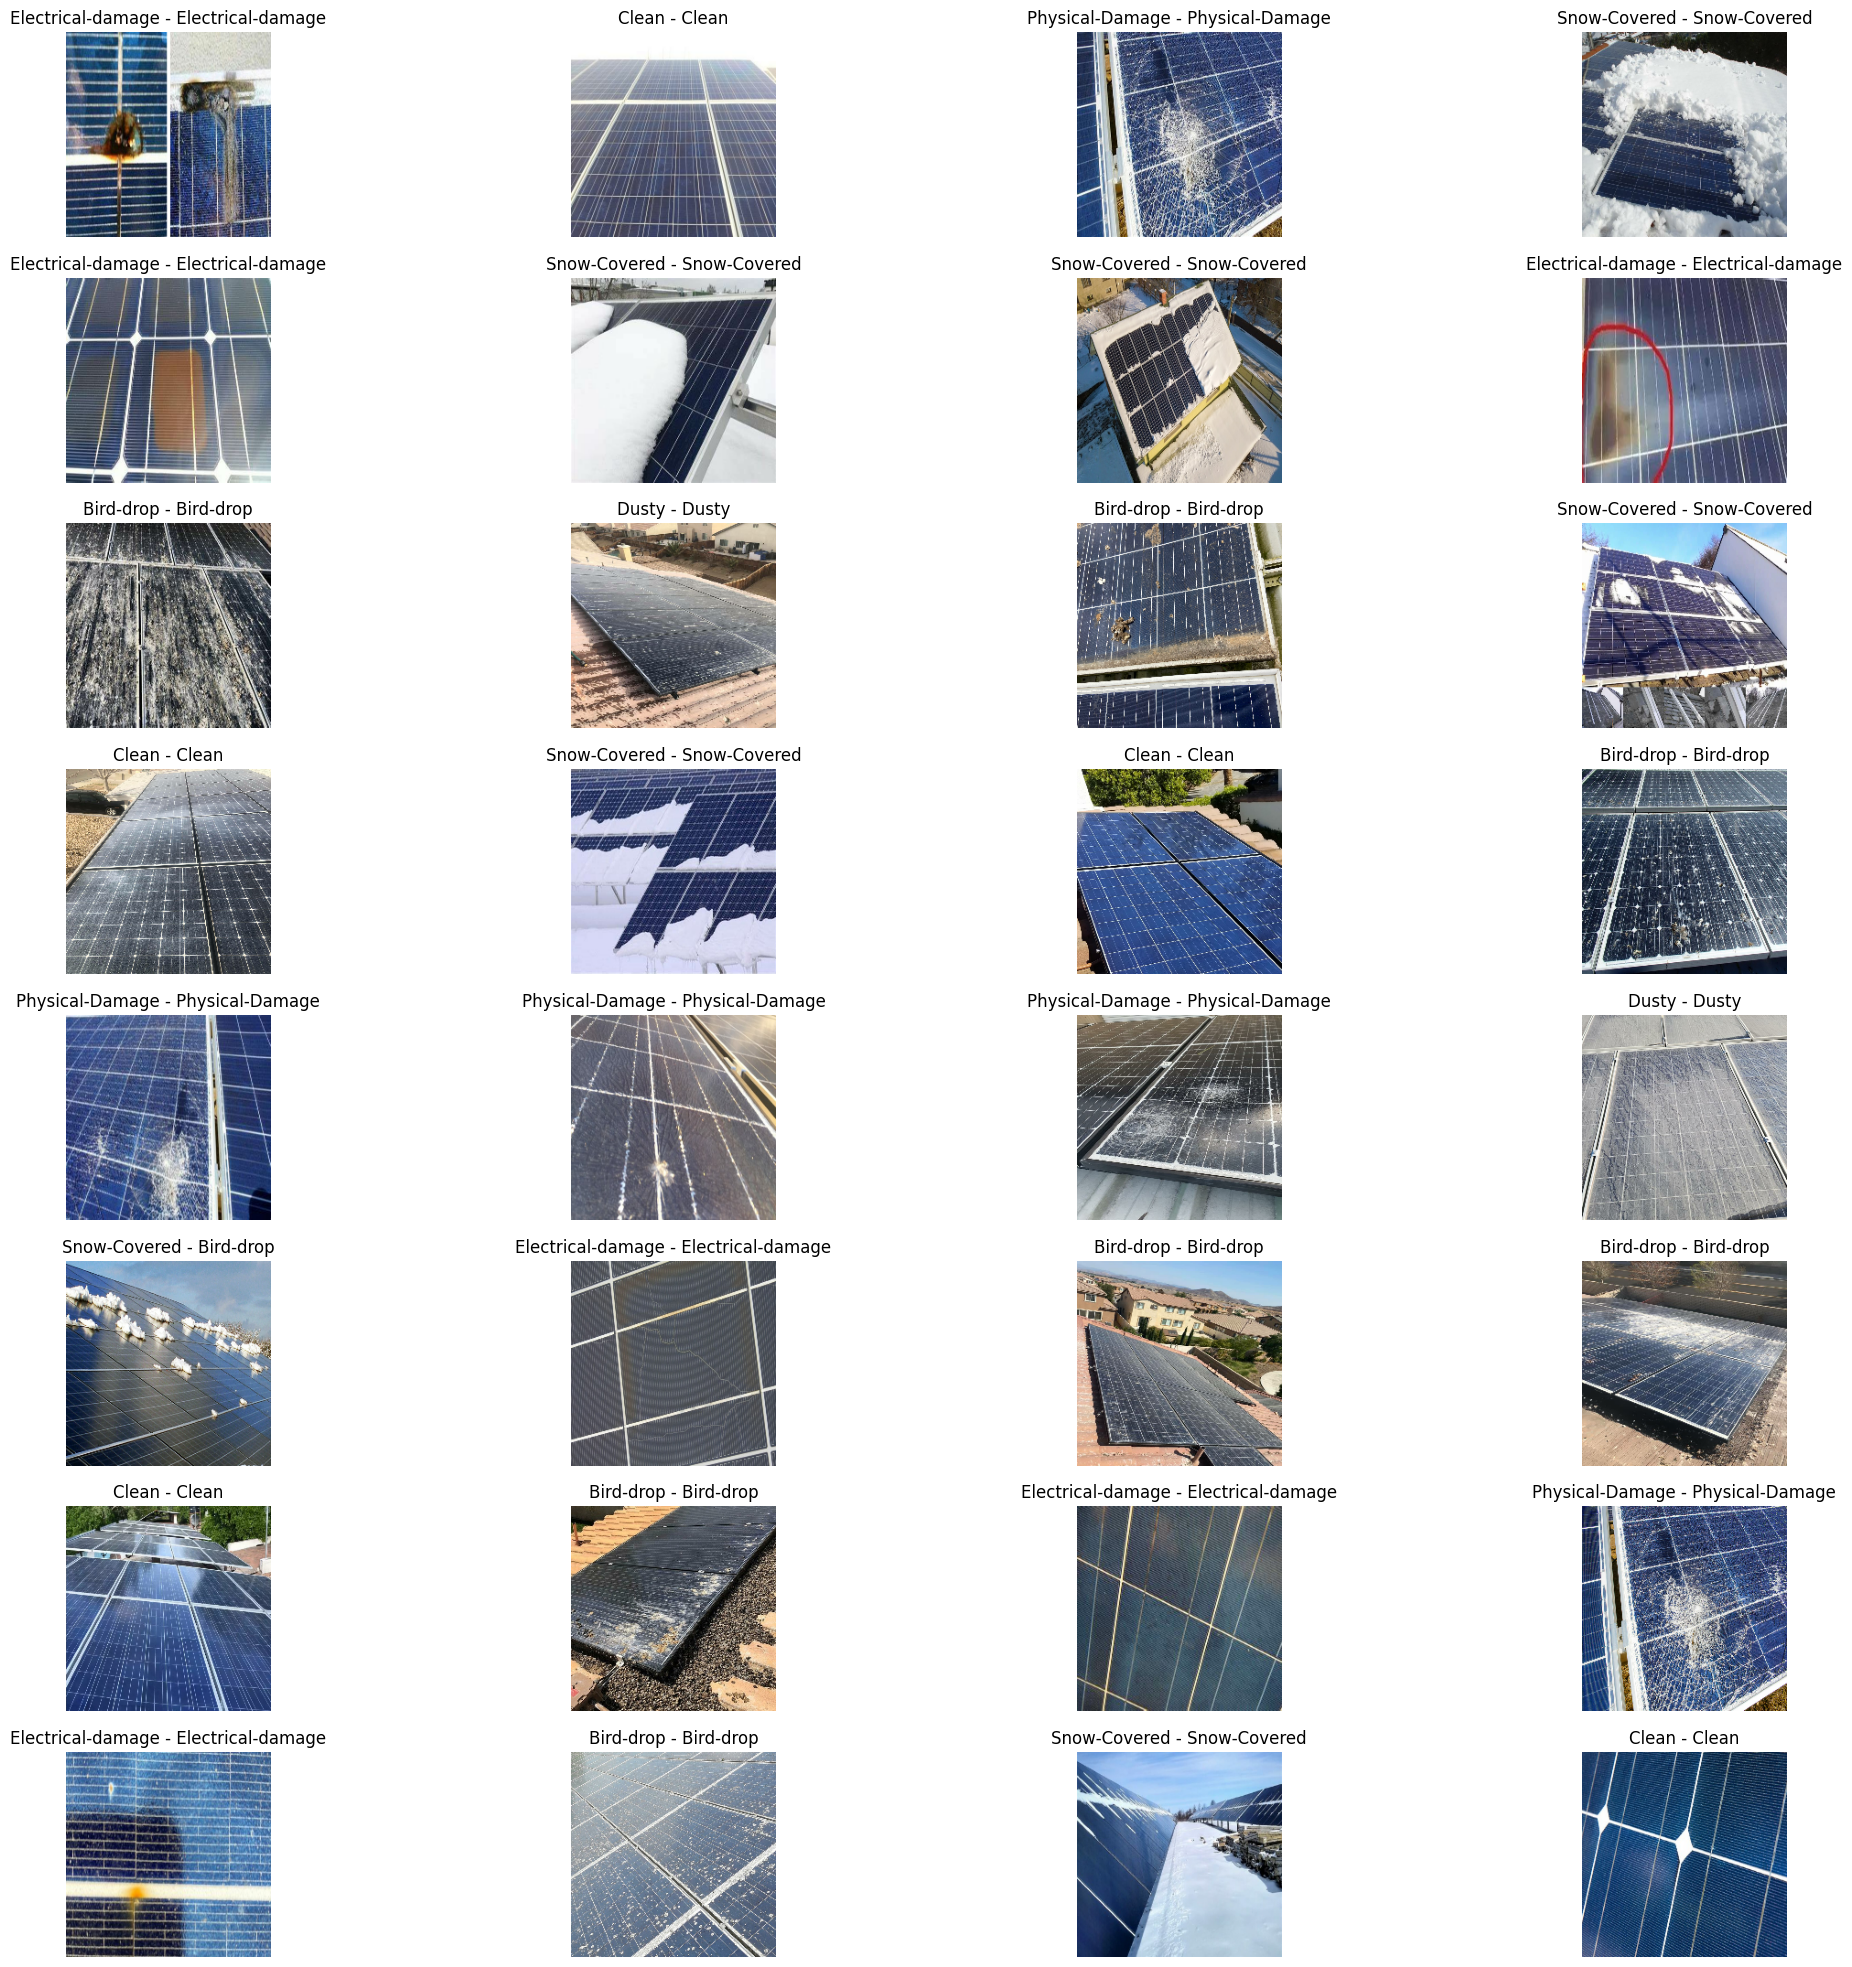

In [16]:
plt.figure(figsize=(25,25))
for i in range(32):
    ax = plt.subplot(8, 4, i + 1)
    plt.imshow(X_val[i].astype("uint8"))
    plt.title(f'{class_names[y_val[i]]} - {class_names[y_pred[i]]}')
    plt.axis("off")

In [17]:
# ── EfficientNetB0 ──────────────────────────────────────────────
eff_base = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
eff_base.trainable = False

eff_model = keras.models.Sequential([
    eff_base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(6, activation='softmax')
])
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
eff_checkpoint = ModelCheckpoint("eff_model.keras", save_best_only=True)
eff_early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [19]:
eff_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
eff_hist = eff_model.fit(
    train, epochs=25,
    validation_data=validation,
    callbacks=[eff_checkpoint, eff_early_stopping]
)

Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.2952 - loss: 1.7280 - val_accuracy: 0.5367 - val_loss: 1.2230
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.5480 - loss: 1.2334 - val_accuracy: 0.6893 - val_loss: 0.9431
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.6384 - loss: 1.0374 - val_accuracy: 0.7458 - val_loss: 0.8018
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.6893 - loss: 0.8978 - val_accuracy: 0.7684 - val_loss: 0.7214
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.7020 - loss: 0.8359 - val_accuracy: 0.8079 - val_loss: 0.6590
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.7359 - loss: 0.7592 - val_accuracy: 0.7910 - val_loss: 0.6106
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.7571 - loss: 0.7154 - val_accuracy: 0.8079 - val_loss: 0.5761
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 0.7867 - loss: 0.6639 - val_accuracy: 0.8192 - val_loss:

In [21]:
eff_hist_ = pd.DataFrame(eff_hist.history)
eff_hist_

,accuracy,loss,val_accuracy,val_loss
0,0.295198,1.728030,0.536723,1.222991
1,0.548023,1.233402,0.689266,0.943061
2,0.638418,1.037355,0.745763,0.801825
3,0.689266,0.897787,0.768362,0.721424
4,0.701977,0.835888,0.807910,0.659019
5,0.735876,0.759153,0.790960,0.610624
6,0.757062,0.715399,0.807910,0.576086
7,0.786723,0.663888,0.819209,0.550736
8,0.781073,0.647292,0.819209,0.525607
9,0.824859,0.582943,0.830508,0.502555


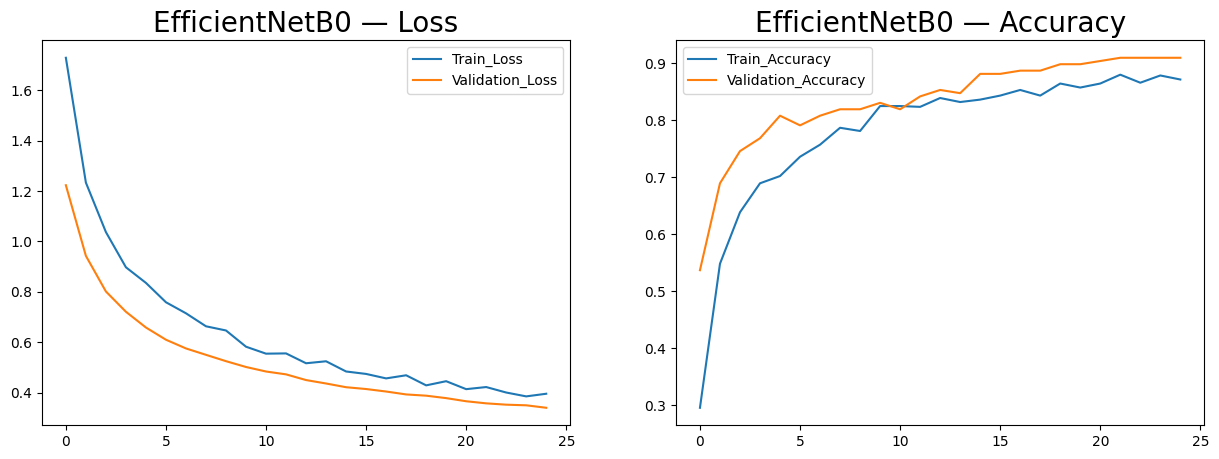

In [22]:

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(eff_hist_['loss'], label='Train_Loss')
plt.plot(eff_hist_['val_loss'], label='Validation_Loss')
plt.title('EfficientNetB0 — Loss', fontsize=20)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eff_hist_['accuracy'], label='Train_Accuracy')
plt.plot(eff_hist_['val_accuracy'], label='Validation_Accuracy')
plt.title('EfficientNetB0 — Accuracy', fontsize=20)
plt.legend()
plt.show()

In [23]:
eff_y_pred = []
predictions_eff = eff_model.predict(np.array(X_val))  # reuses X_val, y_val from MobileNetV2 section
for i in predictions_eff:
    eff_y_pred.append(np.argmax(i))

print("EfficientNetB0 Accuracy:", accuracy_score(y_val, eff_y_pred))
print(classification_report(y_val, eff_y_pred, target_names=class_names))

6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step
EfficientNetB0 Accuracy: 0.9096045197740112
                   precision    recall  f1-score   support

        Bird-drop       0.88      0.96      0.92        48
            Clean       0.92      0.90      0.91        40
            Dusty       0.88      0.72      0.79        29
Electrical-damage       0.90      0.90      0.90        20
  Physical-Damage       1.00      1.00      1.00        13
     Snow-Covered       0.93      1.00      0.96        27

         accuracy                           0.91       177
        macro avg       0.92      0.91      0.91       177
     weighted avg       0.91      0.91      0.91       177

